#### <font color="skyblue">以隨機抽樣的方式計算 PMF (Probability Mass Function)</font>

給定四個數字 (2, 4, 9, 12)。從這四個數字中隨機抽取四個數字（取後放回）並計算其平均數。假設隨機變數 $Y$ 代表這四個數字的平均數。請繪製隨機變數 $Y$ 的 PMF。

本題可以直接計算每個平均數的機率，但在此請使用隨機抽樣的方式，估計出這些機率值。其中抽樣的次數可以高至百萬以上。

<font color="red">注意： 留意取後放回的抽樣方式</font>

本題出自 Statistical Inference by G. Casella & R.L. Berger，此 PMF 可經理論推導得出（如下圖），但在此我們將使用隨機抽樣的方式來估計其 PMF。

<img src="pictures/TruePMF.png" alt="Theoretical PMF" width="400">


<hr>

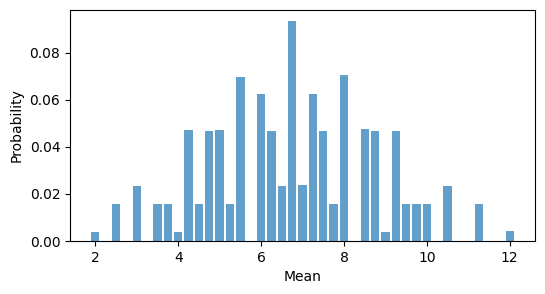

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# 定義數字集合
numbers = np.array([2, 4, 9, 12])
# 隨機抽樣四個數字並計算平均數

# do this 1000 times to get a distribution of means
# do no use for loop, use vectorized operations instead
N = 1000000
y = np.mean(np.random.choice(numbers, size=(N, 4), \
                             replace=True), axis=1)

# y_values = []
# for _ in range(1000000):
#     samples = np.random.choice(numbers, size=4, replace=True)
#     y = np.mean(samples)
#     y_values.append(y)

# y = np.array(y_values)

# 繪製隨機變數 Y 的 PMF
fig, ax = plt.subplots(figsize=(6, 3))
probabilities = np.unique(y, return_counts=True)[1] / len(y)
plt.bar(np.unique(y), probabilities, width=0.2, alpha=0.7)
plt.xlabel('Mean')
plt.ylabel('Probability')
plt.show()

#### <font color="skyblue">驗證統計量分配的蒙地卡羅模擬實驗（一）</font>

令 $\{x_i, i=1,\cdots, n\}$ 代表來自標準常態 $N(0,1)$ 的 $n$ 個隨機樣本。統計量 $G_1$ 表示為

$$G_1 = \sqrt{\frac{n}{6}} \hat{s}$$

其中 $\hat{s}$ 為偏態係數（skewness）的估計值。利用蒙地卡羅模擬（Monte Carlo Simulation）驗證統計量 $G_1$ 服從標準常態 $N(0,1)$。其中蒙地卡羅模擬的環境設定（scenarios）為：

樣本數 $n = 10, 20, 30, 50, 100, 300, 500, 1000$。

針對每個樣本數 $n$，模擬次數皆為 N=50,000。

繪製統計量 $G_1$ 的直方圖與 ECDF 圖。並分別畫上對應的標準常態 PDF 與 CDF 圖。
<hr>

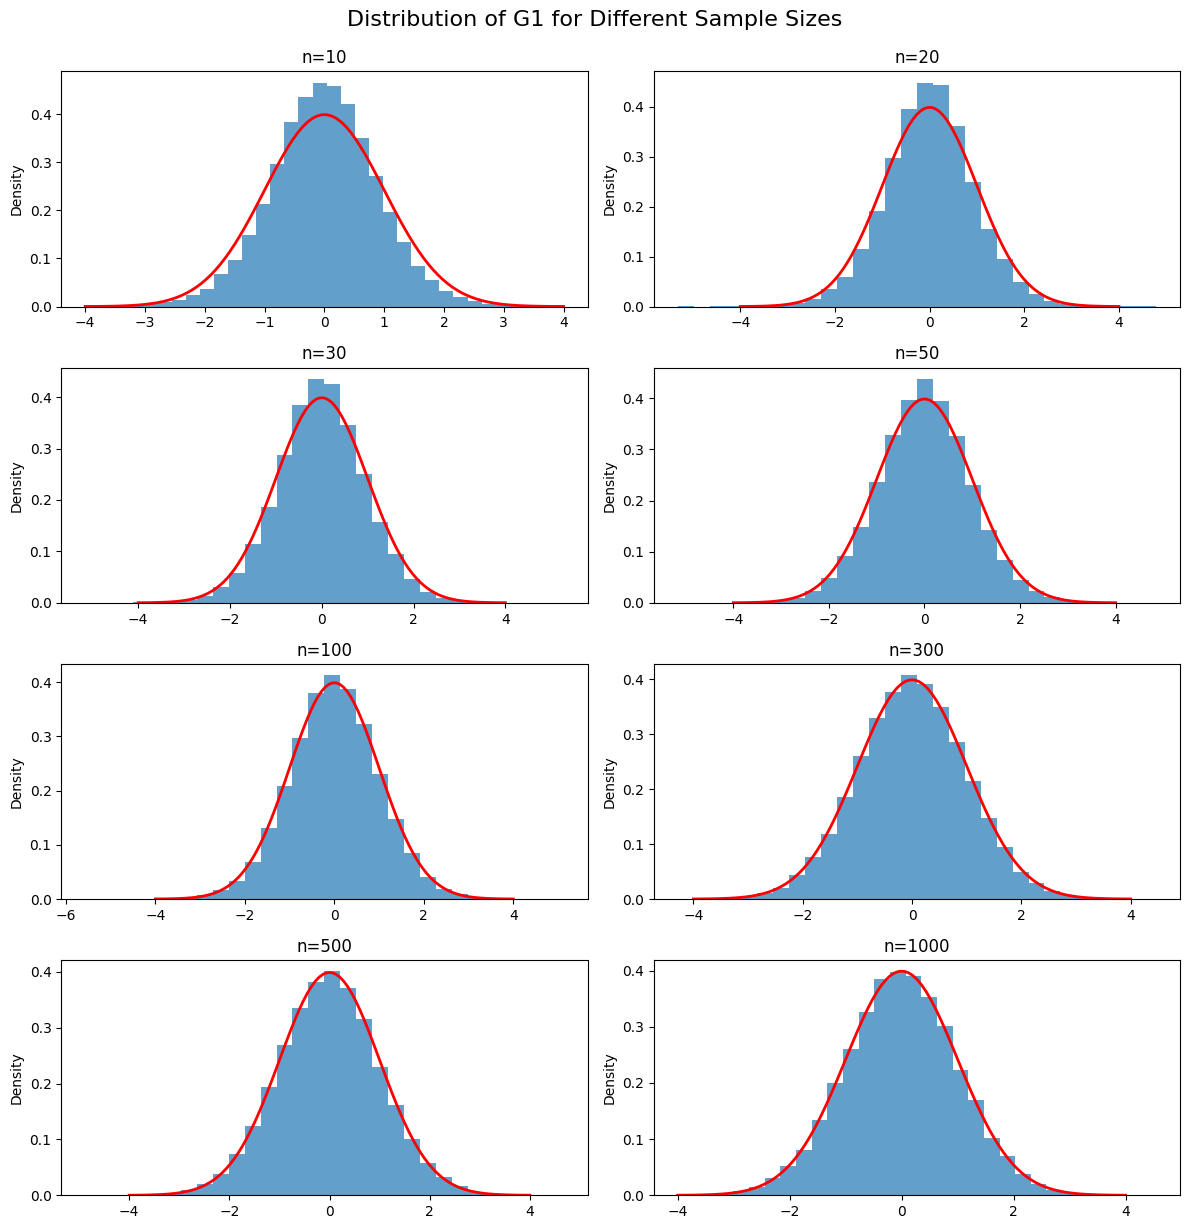

In [17]:
# compute the statistic for G1=sqrt(n/6)* skewness
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, norm

n = [10, 20, 30, 50, 100, 300, 500, 1000]
N = 50000
mu, s = 0, 1

# plot the histogram of G1 for different sample sizes in a 4x2 grid
fig, axs = plt.subplots(4, 2, figsize=(12, 12))
# plot the histogram of G1
for i, n_val in enumerate(n):
    # generate random samples
    samples = np.random.normal(mu, s, (N, n_val))
    # compute G1
    g1_val = np.sqrt(n_val / 6) * skew(samples, axis=1, bias=False)
    ax = axs[i // 2, i % 2]
    ax.hist(g1_val, bins=30, density=True, alpha=0.7)
    # plot the normal distribution for comparison
    x = np.linspace(-4, 4, 100)
    y = norm.pdf(x, 0, 1)
    ax.plot(x, y, 'r-', linewidth=2)
    ax.set_title('n={}'.format(n_val))
    # ax.set_xlabel('G1')
    ax.set_ylabel('Density')

plt.tight_layout()
plt.suptitle('Distribution of G1 for Different Sample Sizes', fontsize=16, y=1.02)
plt.show()


#### <font color="skyblue">驗證統計量分配的蒙地卡羅模擬實驗（二）</font>

同上，但令統計量為

$$G_2 = \sqrt{\frac{n}{24}} (\hat{k} - 3)$$

其中 $\hat{k}$ 為峰態係數（Kurtosis）的估計值。同樣利用蒙地卡羅模擬，驗證統計量 $G_2$ 服從標準常態 $N(0,1)$。蒙地卡羅模擬的環境設定同上。

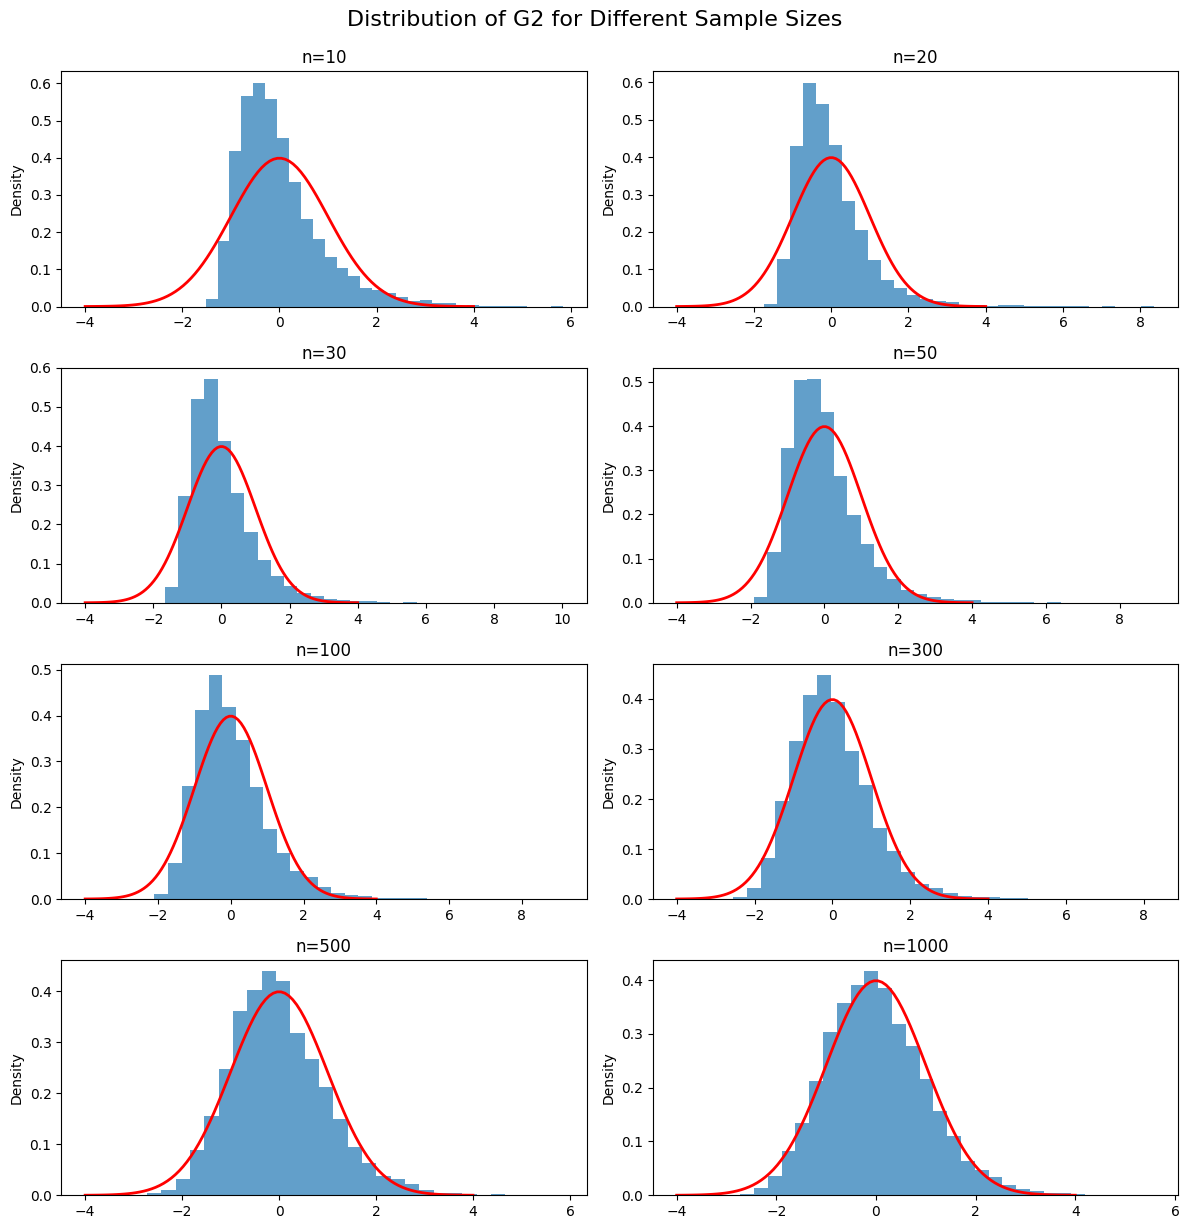

In [20]:
# compute the statistic for G2=sqrt(n/24)* kurtosis
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, norm, kurtosis

n = [10, 20, 30, 50, 100, 300, 500, 1000]
N = 10000
mu, s = 0, 1

# plot the histogram of G2 for different sample sizes in a 4x2 grid
fig, axs = plt.subplots(4, 2, figsize=(12, 12))
# plot the histogram of G2
for i, n_val in enumerate(n):
    # generate random samples
    samples = np.random.normal(mu, s, (N, n_val))
    # compute G2
    g2_val = kurtosis(samples, axis=1, fisher=True, bias=False)
    g2_val = np.sqrt(n_val / 24) * g2_val
    ax = axs[i // 2, i % 2]
    ax.hist(g2_val, bins=30, density=True, alpha=0.7)
    # plot the normal distribution for comparison
    x = np.linspace(-4, 4, 100)
    y = norm.pdf(x, 0, 1)
    ax.plot(x, y, 'r-', linewidth=2)
    ax.set_title('n={}'.format(n_val))
    # ax.set_xlabel('G1')
    ax.set_ylabel('Density')

plt.tight_layout()
plt.suptitle('Distribution of G2 for Different Sample Sizes', fontsize=16, y=1.02)
plt.show()


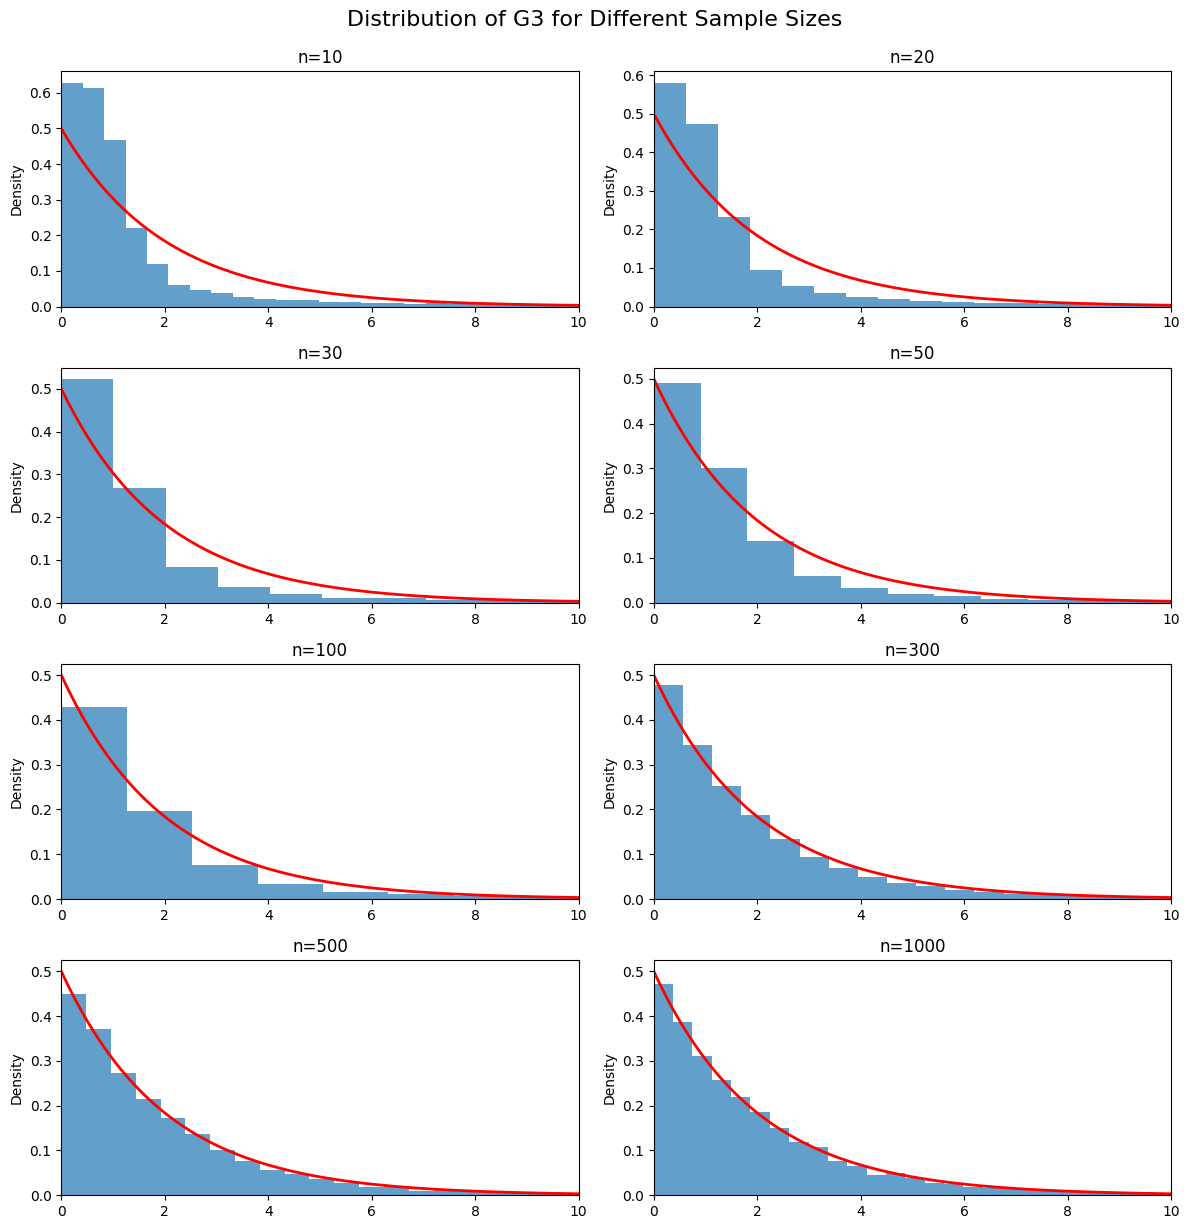

In [25]:
# compute the statistic for G3=G1^2 + G2^2
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, norm, kurtosis, chi2

n = [10, 20, 30, 50, 100, 300, 500, 1000]
N = 10000
mu, s = 0, 1

# plot the histogram of G3 for different sample sizes in a 4x2 grid
fig, axs = plt.subplots(4, 2, figsize=(12, 12))
# plot the histogram of G3
for i, n_val in enumerate(n):
    # generate random samples
    samples = np.random.normal(mu, s, (N, n_val))
    # compute G1
    g1_val = np.sqrt(n_val / 6) * skew(samples, axis=1, bias=False)
    # compute G2
    g2_val = kurtosis(samples, axis=1, fisher=True, bias=False)
    g2_val = np.sqrt(n_val / 24) * g2_val
    # compute G3
    g3_val = g1_val**2 + g2_val**2
    ax = axs[i // 2, i % 2]
    ax.hist(g3_val, bins=100, density=True, alpha=0.7)
    # plot the chi2 distribution for comparison
    x = np.linspace(0, 10, 100)
    y = chi2.pdf(x, 2)
    ax.plot(x, y, 'r-', linewidth=2)
    ax.set_title('n={}'.format(n_val))
    # ax.set_xlabel('G1')
    ax.set_xlim(0, 10)
    ax.set_ylabel('Density')

plt.tight_layout()
plt.suptitle('Distribution of G3 for Different Sample Sizes', fontsize=16, y=1.02)
plt.show()
